# Assignment 14: Ethical AI Analysis and Explainability

**Student Name:** Mohammad Tamim Hamkar

## Step 1: Introduction

AI models can make important decisions that affect people's lives, so it is important to make sure those decisions are fair and understandable.

In this assignment, I will build a machine learning model and examine whether it treats different groups fairly. I will also use explainability tools to better understand how the model makes its predictions.

## Step 2: Import Libraries

Here, I import the libraries needed to prepare the data, train the model, evaluate fairness, and explain the model's predictions.

In [1]:
# Install the libraries needed for fairness and explainability
!pip install fairlearn lime -q

# Data processing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Fairness analysis
from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    false_positive_rate,
    true_positive_rate
)

# Explainability
import shap
from lime.lime_tabular import LimeTabularExplainer

print("Libraries imported successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 6.1 MB/s eta 0:00:00
Libraries imported successfully.


## Step 3: Load the Dataset

For this assignment, I use the Adult Income dataset. The goal is to predict whether a person's income is above $50K per year.

I will use sex as the sensitive attribute to check whether the model performs fairly across different groups.

In [2]:
# Load the Adult Income dataset
from sklearn.datasets import fetch_openml

adult = fetch_openml(
    name="adult",
    version=2,
    as_frame=True
)

df = adult.frame

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (48842, 15)

First 5 rows:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K



Columns:
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'class']


## Step 4: Prepare the Dataset

Select the features and target that will be used to train the model. I also keep sex as the sensitive attribute so I can compare the model's results between groups during the fairness analysis.

In [3]:
# Select numerical features
features = [
    "age",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

# Create features (X)
X = df[features].copy()

# Convert the target into 0 and 1
y = (df["class"] == ">50K").astype(int)

# Keep sex as the sensitive attribute
sensitive_feature = df["sex"].copy()

# Remove rows with missing values
valid_rows = X.notna().all(axis=1) & sensitive_feature.notna()

X = X[valid_rows]
y = y[valid_rows]
sensitive_feature = sensitive_feature[valid_rows]

print("Features shape:", X.shape)
print("\nTarget values:")
print(y.value_counts())

print("\nSensitive attribute:")
print(sensitive_feature.value_counts())

Features shape: (48842, 5)

Target values:
class
0    37155
1    11687
Name: count, dtype: int64

Sensitive attribute:
sex
Male      32650
Female    16192
Name: count, dtype: int64


## Step 5: Split and Scale the Data

The dataset is divided into training and testing sets. The numerical features are standardized to keep them on a similar scale before training the Logistic Regression model.

In [4]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test, sensitive_train, sensitive_test = train_test_split(
    X,
    y,
    sensitive_feature,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Standardize the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nSensitive groups in testing data:")
print(sensitive_test.value_counts())

Training set: (39073, 5)
Testing set: (9769, 5)

Sensitive groups in testing data:
sex
Male      6510
Female    3259
Name: count, dtype: int64


## Step 6: Train the Logistic Regression Model

A Logistic Regression model is trained using the prepared training data. This model will predict whether a person's annual income is above $50K.

In [5]:
# Create and train the Logistic Regression model
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

# Make predictions on the testing data
y_pred = model.predict(X_test_scaled)

print("Model trained successfully.")

Model trained successfully.


## Step 7: Evaluate the Model

The model's performance is evaluated using accuracy, a confusion matrix, and a classification report. These results show how well the model predicts the two income categories.

In [6]:
# Calculate model accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

# Display confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 81.93 %

Confusion Matrix:
[[7100  331]
 [1434  904]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      7431
           1       0.73      0.39      0.51      2338

    accuracy                           0.82      9769
   macro avg       0.78      0.67      0.70      9769
weighted avg       0.81      0.82      0.80      9769



## Step 8: Fairness Analysis with Fairlearn

Fairness is evaluated across male and female groups using selection rate, false positive rate, and true positive rate. Comparing these metrics helps identify whether the model behaves differently across the sensitive groups.

In [7]:
# Define the fairness metrics
fairness_metrics = {
    "Selection Rate": selection_rate,
    "False Positive Rate": false_positive_rate,
    "True Positive Rate": true_positive_rate
}

# Create a MetricFrame to compare groups
metric_frame = MetricFrame(
    metrics=fairness_metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_test
)

print("Fairness Metrics by Sex:")
display(metric_frame.by_group)

Fairness Metrics by Sex:


,Selection Rate,False Positive Rate,True Positive Rate
sex,,,
Female,0.076711,0.036232,0.401662
Male,0.151306,0.049857,0.383915


## Step 9: Visualize Fairness Metrics

The fairness metrics are shown in bar charts to make the differences between male and female groups easier to compare and understand.

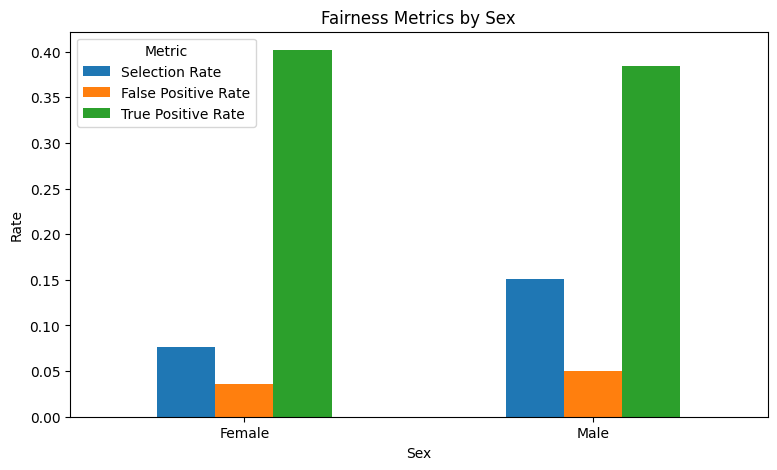

In [8]:
# Create bar plots for the fairness metrics
metric_frame.by_group.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Fairness Metrics by Sex")
plt.ylabel("Rate")
plt.xlabel("Sex")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.show()

## Step 10: SHAP Global Explainability

SHAP helps explain how different features influence the model's predictions. The summary plot shows which features have the greatest overall impact on the Logistic Regression model.

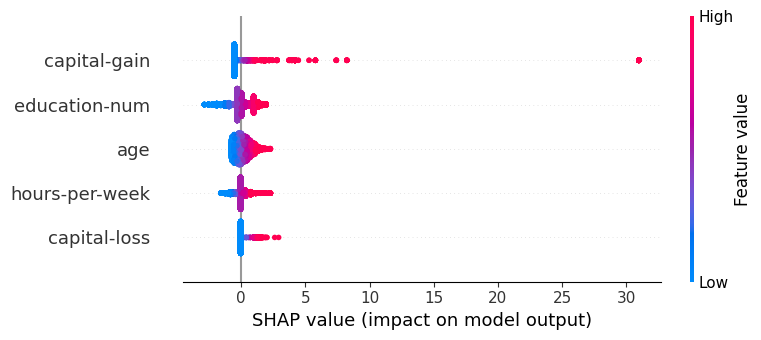

In [9]:
# Create a SHAP explainer for the Logistic Regression model
explainer = shap.LinearExplainer(
    model,
    X_train_scaled,
    feature_names=features
)

# Calculate SHAP values for the test data
shap_values = explainer(X_test_scaled)

# Create a SHAP summary plot
shap.summary_plot(
    shap_values.values,
    X_test_scaled,
    feature_names=features
)

## Step 11: SHAP Local Explainability

A SHAP waterfall plot explains one individual prediction. It shows which features pushed the prediction higher or lower, making the model's decision easier to understand.

Predicted class: 0
Actual class: 0


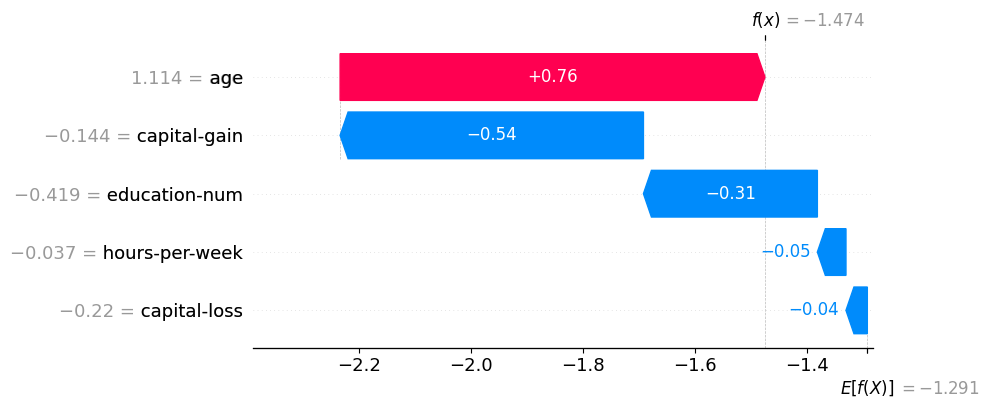

In [10]:
# Select one person from the test data
sample_index = 0

# Display the model's prediction
predicted_class = model.predict(
    X_test_scaled[sample_index].reshape(1, -1)
)[0]

print("Predicted class:", predicted_class)
print("Actual class:", y_test.iloc[sample_index])

# Create a SHAP waterfall plot for this prediction
shap.plots.waterfall(shap_values[sample_index])

## Step 12: LIME Explainability

LIME provides another way to understand an individual prediction. It identifies the features that had the strongest influence on the model's decision for one person.

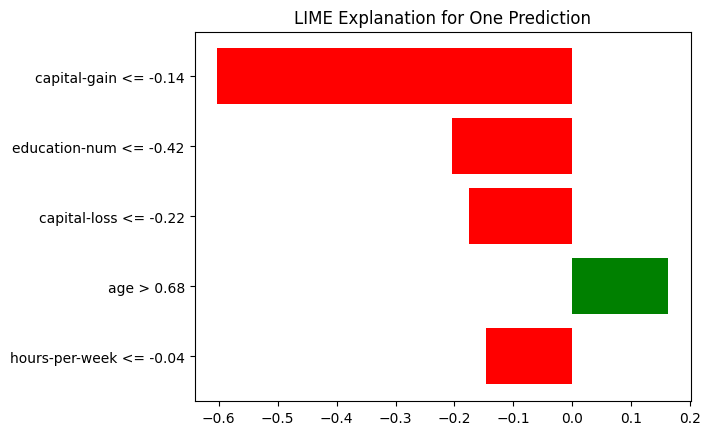

LIME Feature Contributions:
capital-gain <= -0.14 : -0.6026
education-num <= -0.42 : -0.204
capital-loss <= -0.22 : -0.1751
age > 0.68 : 0.1623
hours-per-week <= -0.04 : -0.1459


In [11]:
# Create the LIME explainer
lime_explainer = LimeTabularExplainer(
    X_train_scaled,
    feature_names=features,
    class_names=["<=50K", ">50K"],
    mode="classification",
    random_state=42
)

# Explain the same individual prediction
lime_explanation = lime_explainer.explain_instance(
    X_test_scaled[0],
    model.predict_proba,
    num_features=5
)

# Display the LIME explanation
lime_explanation.as_pyplot_figure()
plt.title("LIME Explanation for One Prediction")
plt.show()

# Display the feature contributions
print("LIME Feature Contributions:")
for feature, contribution in lime_explanation.as_list():
    print(feature, ":", round(contribution, 4))

## Step 13: Findings and Ethical Considerations

The model reached 81.93% accuracy, but I learned that a good accuracy score does not always mean a model is completely fair. The model was better at identifying people in the lower-income group than people in the higher-income group.

When I compared the results by sex, I noticed a difference in the selection rates. The selection rate was about 7.67% for females and 15.13% for males. This does not automatically mean the model is biased, but it shows that differences between groups need to be looked at carefully.

SHAP and LIME also helped me understand why the model made certain predictions. SHAP showed which features were most important overall, while LIME helped explain one individual prediction.

To make a model like this more fair and responsible, I think the data should be checked for possible bias, results should be compared across different groups, and the model should be monitored regularly. Human judgment should also be part of important decisions instead of relying only on AI.

## Step 14: Conclusion

This assignment helped me understand that Ethical AI is not only about creating a model that gives accurate predictions. It is also important to know whether the model treats different groups fairly and to understand why it makes certain decisions.

Using Fairlearn showed me how model results can be compared between groups. SHAP and LIME helped me see how different features influenced the predictions. Overall, I learned that fairness, transparency, and human judgment are important when AI is used in real-world situations.